# Evaluation Framework — Backtest Harness & Metrics

**Project phase:** Phase 3 — *Evaluation framework* (see `ROADMAP.md`)

> ROADMAP principle #1: *fix the evaluation before writing any model.* If the split or metric
> changes later, every comparison collapses. So this notebook is built **before** the baselines.

This notebook defines the **contract** that every later model (SeasonalNaive, ETS/ARIMA, LightGBM,
PatchTST, Chronos) is measured against — the same split, the same rolling-origin backtest, the same
metrics — and validates it end-to-end with the first baseline.

## The on-disk contract (notebook-first, but everything persists)
Models live in separate notebooks, yet stay comparable because they communicate **through disk**:

| Artifact | Path | Written by | Read by |
|---|---|---|---|
| Backtest windows (cutoffs) | `data/processed/backtest_windows.parquet` | this notebook | every model notebook |
| Per-model forecasts (tidy) | `results/forecasts/<model>.parquet` | each model notebook | the evaluator here |
| Per-model metric summary | `results/metrics/<model>_summary.csv` | the evaluator | reports / benchmark |
| Leaderboard (all models) | `results/metrics/leaderboard.csv` | the evaluator | reports / benchmark |

**Evaluation is centralized.** A model notebook only has to (1) read the shared cutoffs and (2) write
forecasts in the agreed schema. It never re-implements a metric, so all models are scored identically.

### Forecast schema (`results/forecasts/<model>.parquet`)
`model, unique_id, cutoff, ds, horizon (1..H), y (actual), q10, q20, …, q90`  — point forecast = `q50`.

---
### Contents
1. Setup & configuration
2. Load data
3. Rolling-origin backtest windows
4. Metrics (definitions)
5. Metric validation on synthetic data
6. Backtest orchestrator & forecast I/O
7. First baseline — SeasonalNaive (the bar to beat)
8. Centralized evaluation & leaderboard
9. Forecast-vs-actual inspection
10. Summary & the contract for model notebooks

## 1. Setup & configuration

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 4.5)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")


def find_project_root(marker="data/electricity_hourly_dataset.tsf"):
    here = Path.cwd()
    for base in [here, *here.parents]:
        if (base / marker).exists():
            return base
    raise FileNotFoundError(f"Could not locate {marker} from {here}")


PROJECT_ROOT = find_project_root()
INTERIM = PROJECT_ROOT / "data" / "interim"
PROCESSED = PROJECT_ROOT / "data" / "processed"
FORECASTS = PROJECT_ROOT / "results" / "forecasts"
METRICS = PROJECT_ROOT / "results" / "metrics"
FIG_DIR = PROJECT_ROOT / "reports" / "figures"
for d in (PROCESSED, FORECASTS, METRICS, FIG_DIR):
    d.mkdir(parents=True, exist_ok=True)

# --- Evaluation constants (kept in sync with ROADMAP.md; the single source of truth) ---
HORIZON = 168                       # forecast 1 week ahead (Monash standard)
SEASONALITY = 24                    # MASE seasonal period m (daily); confirmed dominant in EDA §9
QUANTILE_LEVELS = [round(0.1 * i, 1) for i in range(1, 10)]   # 0.1 .. 0.9
POINT_Q = 0.5
N_WINDOWS = 5                       # rolling-origin cutoffs -> variance estimate
STEP = HORIZON                      # non-overlapping weekly windows
COVERAGE_LO, COVERAGE_HI = 0.1, 0.9  # 80% central prediction interval

print(f"HORIZON={HORIZON}  SEASONALITY={SEASONALITY}  N_WINDOWS={N_WINDOWS}  STEP={STEP}")
print(f"Quantile levels: {QUANTILE_LEVELS}")
print("Project root:", PROJECT_ROOT)

HORIZON=168  SEASONALITY=24  N_WINDOWS=5  STEP=168
Quantile levels: [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
Project root: /Users/mskayacioglu/Documents/projects/energy-demand-forecasting-foundation-models


## 2. Load data

We reuse the tidy long-format Parquet produced by the EDA notebook and pivot it to a wide
`DatetimeIndex × series` matrix, which makes the vectorized backtest fast.

In [2]:
long = pd.read_parquet(INTERIM / "electricity_hourly_long.parquet")
wide = (
    long.pivot(index="ds", columns="unique_id", values="y")
    .sort_index()
    .astype("float64")
)
wide.columns = wide.columns.astype(str)
SERIES = wide.columns                      # canonical series order used everywhere below
INDEX = wide.index                         # hourly DatetimeIndex

print("wide shape :", wide.shape)
print("series     :", len(SERIES))
print("date range :", INDEX.min(), "->", INDEX.max())
assert wide.isna().sum().sum() == 0, "unexpected NaNs after pivot"

wide shape : (26304, 321)
series     : 321
date range : 2012-01-01 00:00:00 -> 2014-12-31 23:00:00


## 3. Rolling-origin backtest windows

A single test window can mislead, so we evaluate on **`N_WINDOWS` non-overlapping weekly windows**
walking backward from the end of the data. For window *k* the model trains on everything up to and
including `cutoff_k`, then forecasts the next `HORIZON` hours.

* The most recent window (`k = 0`, covering the final week) is the **official test week** from the
  ROADMAP; the earlier windows add robustness / a variance estimate.
* Everything `<= cutoff` is train — no future information leaks across the cutoff.

The windows are saved so **every model notebook reads the exact same cutoffs**.

In [3]:
def make_windows(index, n_windows, horizon, step):
    last_pos = len(index) - 1
    rows = []
    for k in range(n_windows):
        cutoff_pos = last_pos - horizon - k * step   # last train position for window k
        if cutoff_pos - SEASONALITY < 0:
            raise ValueError("Not enough history for the requested windows.")
        rows.append({
            "window": k,
            "cutoff_pos": cutoff_pos,
            "cutoff": index[cutoff_pos],
            "first_forecast": index[cutoff_pos + 1],
            "last_forecast": index[cutoff_pos + horizon],
        })
    return pd.DataFrame(rows).sort_values("window", ignore_index=True)


windows = make_windows(INDEX, N_WINDOWS, HORIZON, STEP)
windows.to_parquet(PROCESSED / "backtest_windows.parquet", index=False)
print("Saved cutoffs -> data/processed/backtest_windows.parquet")
windows

Saved cutoffs -> data/processed/backtest_windows.parquet


,window,cutoff_pos,cutoff,first_forecast,last_forecast
0,0,26135,2014-12-24 23:00:00,2014-12-25,2014-12-31 23:00:00
1,1,25967,2014-12-17 23:00:00,2014-12-18,2014-12-24 23:00:00
2,2,25799,2014-12-10 23:00:00,2014-12-11,2014-12-17 23:00:00
3,3,25631,2014-12-03 23:00:00,2014-12-04,2014-12-10 23:00:00
4,4,25463,2014-11-26 23:00:00,2014-11-27,2014-12-03 23:00:00


## 4. Metrics (definitions)

All metrics operate on arrays shaped `(HORIZON, n_series)` for one cutoff and are **hand-rolled** for
full transparency and control over edge cases (no hidden library conventions). They are validated
against known values in §5, and can be cross-checked against `utilsforecast` once the model libraries
are installed.

* **MAE / RMSE** — scale-dependent point error.
* **sMAPE** — symmetric percentage error, `0/0 → 0`.
* **MASE** — MAE divided by the in-sample seasonal-naive MAE of the **training** series
  (`mean|y_t − y_{t−m}|`, `m = SEASONALITY`). Scale-free and the primary ranking metric. Series whose
  training window is seasonally constant give a zero denominator → reported as `NaN` and excluded.
* **WQL** — mean weighted quantile (pinball) loss over `QUANTILE_LEVELS`, normalized by `Σ|y|`
  (GluonTS/Chronos convention; the `×2` makes `q=0.5` reduce to normalized MAE).
* **Coverage@80** — empirical fraction of actuals inside the `[q10, q90]` interval (nominal 0.80).

In [4]:
def mae(y, p):        return np.abs(y - p).mean(axis=0)
def rmse(y, p):       return np.sqrt(((y - p) ** 2).mean(axis=0))

def smape(y, p):
    den = np.abs(y) + np.abs(p)
    val = np.where(den == 0, 0.0, 2.0 * np.abs(p - y) / den)
    return val.mean(axis=0) * 100.0

def seasonal_naive_denom(train_wide, m):
    '''In-sample seasonal-naive MAE per series: mean|y_t - y_{t-m}| over the training portion.'''
    a = train_wide.to_numpy()
    return np.abs(a[m:] - a[:-m]).mean(axis=0)          # (n_series,)

def mase(y, p, denom):
    d = np.where(denom == 0, np.nan, denom)
    return mae(y, p) / d

def pinball(y, q_pred, q):
    e = y - q_pred
    return np.maximum(q * e, (q - 1) * e)

def wql(y, quant_preds, levels):
    '''Mean weighted quantile loss per series; quant_preds: {level: (H,n) array}.'''
    num = np.zeros(y.shape[1])
    for q in levels:
        num += 2.0 * pinball(y, quant_preds[q], q).sum(axis=0)
    denom = np.abs(y).sum(axis=0)
    denom = np.where(denom == 0, np.nan, denom)
    return (num / len(levels)) / denom

def coverage(y, lo, hi):
    return ((y >= lo) & (y <= hi)).mean(axis=0)

## 5. Metric validation on synthetic data

Before trusting the harness we check each metric against a case whose answer we can compute by hand
(ROADMAP Phase-3 DoD: *"the metric pipeline is tested with a fake forecast"*).

In [5]:
# Deterministic point-error checks -------------------------------------------------
y = np.array([[10.0], [20.0], [30.0], [40.0]])       # (4, 1)
p = y + np.array([[2.0], [-2.0], [2.0], [-2.0]])     # constant abs error of 2
assert np.allclose(mae(y, p), 2.0)
assert np.allclose(rmse(y, p), 2.0)

# sMAPE 0/0 handling
assert np.allclose(smape(np.zeros((3, 1)), np.zeros((3, 1))), 0.0)

# Pinball at q=0.5 equals 0.5*|e|; WQL(q=0.5 only) equals normalized MAE
e = y - p
assert np.allclose(pinball(y, p, 0.5), 0.5 * np.abs(e))
wql_median_only = wql(y, {0.5: p}, [0.5])
assert np.allclose(wql_median_only, np.abs(e).sum(0) / np.abs(y).sum(0))

# MASE: forecast MAE / in-sample seasonal-naive MAE
train = pd.DataFrame({"s": [1.0, 3.0, 2.0, 6.0, 4.0, 9.0]})   # m=2 seasonal |diffs|=[1,3,2,3] -> mean 2.25
denom = seasonal_naive_denom(train, m=2)
assert np.allclose(denom, 2.25)
assert np.allclose(mase(y, p, denom), 2.0 / 2.25)

# Coverage: 3 of 4 points inside [ -inf, 35 ] style interval
lo = np.array([[0.0]] * 4); hi = np.array([[35.0]] * 4)
assert np.allclose(coverage(y, lo, hi), 0.75)

print("All metric sanity checks passed.")

All metric sanity checks passed.


## 6. Backtest orchestrator & forecast I/O

A model is a function `model_fn(train_wide, h) -> forecast`, where the forecast is either

* an `(h, n_series)` array (deterministic / point model — reused for every quantile), or
* a dict `{quantile_level: (h, n_series) array}` (probabilistic model).

`run_backtest` loops the shared cutoffs, calls the model on the training slice, assembles the tidy
forecast frame in the contract schema, and saves it to `results/forecasts/<name>.parquet`.

In [6]:
QCOLS = {q: f"q{int(q * 100):02d}" for q in QUANTILE_LEVELS}   # 0.1 -> 'q10'


def run_backtest(model_fn, name, save=True):
    n = len(SERIES)
    uid = np.tile(SERIES.to_numpy(), HORIZON)
    horizon_idx = np.repeat(np.arange(1, HORIZON + 1), n)
    blocks = []
    for _, w in windows.iterrows():
        pos = int(w["cutoff_pos"])
        train = wide.iloc[: pos + 1]
        y_true = wide.iloc[pos + 1 : pos + 1 + HORIZON].to_numpy()      # (H, n)
        ds = wide.index[pos + 1 : pos + 1 + HORIZON]

        preds = model_fn(train, HORIZON)
        if not isinstance(preds, dict):
            preds = {q: preds for q in QUANTILE_LEVELS}

        block = pd.DataFrame({
            "model": name,
            "unique_id": uid,
            "cutoff": w["cutoff"],
            "ds": np.repeat(ds.to_numpy(), n),
            "horizon": horizon_idx,
            "y": y_true.reshape(-1),
        })
        for q, col in QCOLS.items():
            block[col] = np.asarray(preds[q]).reshape(-1)
        blocks.append(block)

    fc = pd.concat(blocks, ignore_index=True)
    if save:
        path = FORECASTS / f"{name}.parquet"
        fc.to_parquet(path, index=False)
        print(f"[{name}] saved {len(fc):,} rows -> results/forecasts/{name}.parquet")
    return fc

## 7. First baseline — SeasonalNaive (the bar to beat)

SeasonalNaive repeats the last observed season. We run it at **m = 24** (daily, the primary MASE
period) and **m = 168** (weekly). This is deterministic, so its quantiles all equal the point
forecast — its probabilistic metrics are therefore uninformative here (that is expected; §5 already
validated WQL/coverage on synthetic data). The point of this run is to exercise the *whole* pipeline
with a real model and to plant the **score every future model must beat**.

In [7]:
def seasonal_naive(m):
    def _fn(train_wide, h):
        last = train_wide.to_numpy()[-m:]                 # (m, n)
        reps = int(np.ceil(h / m))
        return np.tile(last, (reps, 1))[:h]               # (h, n)
    return _fn


fc_snaive24 = run_backtest(seasonal_naive(24), "seasonal_naive_24")
fc_snaive168 = run_backtest(seasonal_naive(168), "seasonal_naive_168")
fc_snaive24.head()

[seasonal_naive_24] saved 269,640 rows -> results/forecasts/seasonal_naive_24.parquet


[seasonal_naive_168] saved 269,640 rows -> results/forecasts/seasonal_naive_168.parquet


,model,unique_id,cutoff,ds,horizon,y,q10,q20,q30,q40,q50,q60,q70,q80,q90
0,seasonal_naive_24,T1,2014-12-24 23:00:00,2014-12-25,1,11.0000,10.0000,10.0000,10.0000,10.0000,10.0000,10.0000,10.0000,10.0000,10.0000
1,seasonal_naive_24,T10,2014-12-24 23:00:00,2014-12-25,1,243.0000,267.0000,267.0000,267.0000,267.0000,267.0000,267.0000,267.0000,267.0000,267.0000
2,seasonal_naive_24,T100,2014-12-24 23:00:00,2014-12-25,1,47.0000,195.0000,195.0000,195.0000,195.0000,195.0000,195.0000,195.0000,195.0000,195.0000
3,seasonal_naive_24,T101,2014-12-24 23:00:00,2014-12-25,1,337.0000,"1,423.0000","1,423.0000","1,423.0000","1,423.0000","1,423.0000","1,423.0000","1,423.0000","1,423.0000","1,423.0000"
4,seasonal_naive_24,T102,2014-12-24 23:00:00,2014-12-25,1,33.0000,158.0000,158.0000,158.0000,158.0000,158.0000,158.0000,158.0000,158.0000,158.0000


## 8. Centralized evaluation & leaderboard

`evaluate` reads any forecast file that follows the schema and scores it identically — this is the
single place metrics are computed. It returns overall and per-cutoff numbers, writes a per-model
summary, and updates the shared leaderboard. Later model notebooks reuse this by pointing it at their
own `results/forecasts/<model>.parquet`.

In [8]:
def _pivot(g, col):
    return (
        g.pivot_table(index="horizon", columns="unique_id", values=col)
        .reindex(columns=SERIES)
        .to_numpy()
    )


def evaluate(name, m=SEASONALITY, write=True):
    fc = pd.read_parquet(FORECASTS / f"{name}.parquet")
    per_window = []
    for cutoff, g in fc.groupby("cutoff", sort=True):
        pos = int(INDEX.get_loc(cutoff))
        denom = seasonal_naive_denom(wide.iloc[: pos + 1], m)     # (n,)
        y = _pivot(g, "y")
        p50 = _pivot(g, QCOLS[POINT_Q])
        quant = {q: _pivot(g, QCOLS[q]) for q in QUANTILE_LEVELS}
        per_window.append(pd.DataFrame({
            "cutoff": cutoff,
            "unique_id": SERIES,
            "MAE": mae(y, p50),
            "RMSE": rmse(y, p50),
            "sMAPE": smape(y, p50),
            "MASE": mase(y, p50, denom),
            "WQL": wql(y, quant, QUANTILE_LEVELS),
            "coverage80": coverage(y, quant[COVERAGE_LO], quant[COVERAGE_HI]),
        }))
    per = pd.concat(per_window, ignore_index=True)

    metric_cols = ["MAE", "RMSE", "sMAPE", "MASE", "WQL", "coverage80"]
    overall = per[metric_cols].mean(numeric_only=True)          # mean over (series, window)
    overall["model"] = name
    overall["n_excluded_MASE"] = int(per["MASE"].isna().sum())
    if write:
        by_window = per.groupby("cutoff")[metric_cols].mean()
        per.to_csv(METRICS / f"{name}_per_series.csv", index=False)
        by_window.to_csv(METRICS / f"{name}_by_window.csv")
        pd.DataFrame([overall]).to_csv(METRICS / f"{name}_summary.csv", index=False)
    return overall, per


def update_leaderboard(*overalls):
    path = METRICS / "leaderboard.csv"
    cols = ["model", "MASE", "sMAPE", "RMSE", "MAE", "WQL", "coverage80", "n_excluded_MASE"]
    new = pd.DataFrame(list(overalls))[cols]
    if path.exists():
        board = pd.read_csv(path)
        board = board[~board["model"].isin(new["model"])]
        board = pd.concat([board, new], ignore_index=True)
    else:
        board = new
    board = board.sort_values("MASE", ignore_index=True)
    board.to_csv(path, index=False)
    return board


ov24, per24 = evaluate("seasonal_naive_24")
ov168, per168 = evaluate("seasonal_naive_168")
board = update_leaderboard(ov24, ov168)
print(f"MASE-excluded series (seasonally-constant train): {int(ov24['n_excluded_MASE'])}")
board

MASE-excluded series (seasonally-constant train): 0


,model,MASE,sMAPE,RMSE,MAE,WQL,coverage80,n_excluded_MASE
0,seasonal_naive_168,1.1130,11.7106,276.1232,174.2054,0.1279,0.0953,0
1,seasonal_naive_24,1.2993,14.3281,315.0868,207.0601,0.1527,0.0445,0


## 9. Forecast-vs-actual inspection

A quick visual on the most recent window: two representative series (one high-volume, one small) with
the SeasonalNaive(24) forecast overlaid on the actuals.

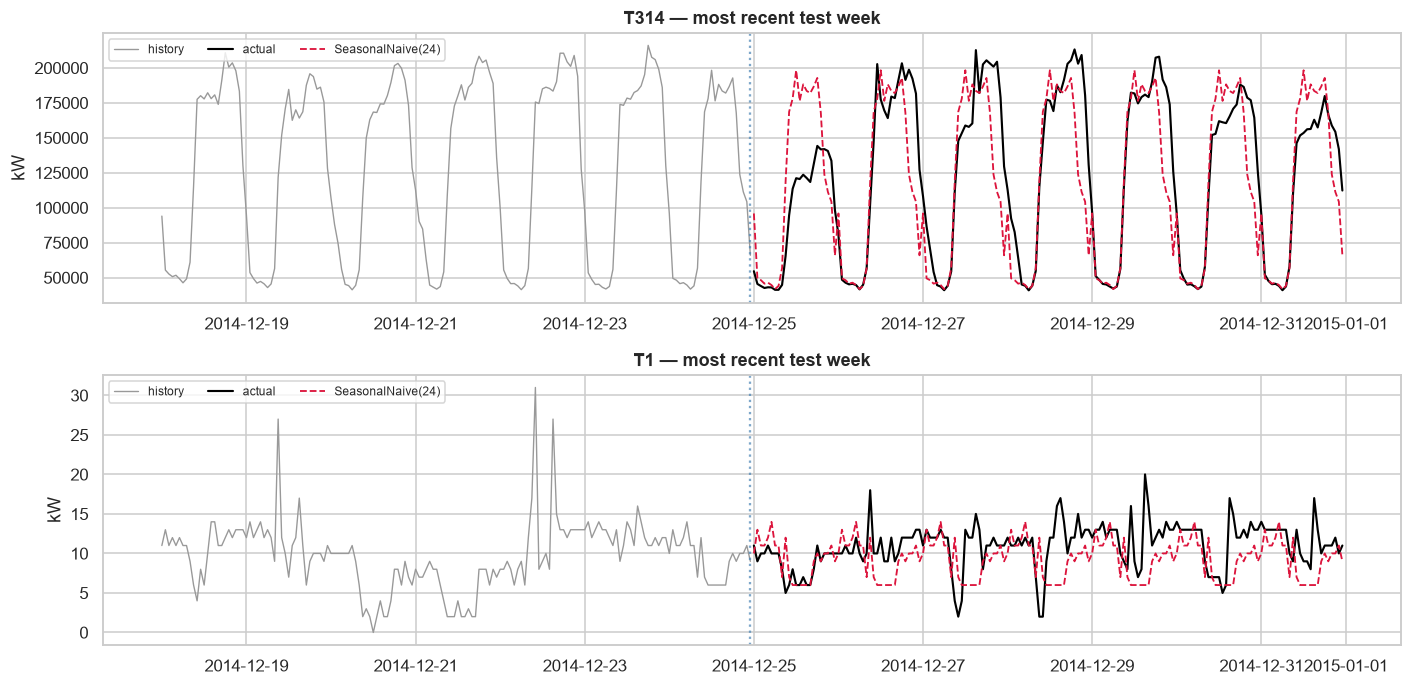

In [9]:
recent = windows.loc[windows["window"] == 0].iloc[0]
pos = int(recent["cutoff_pos"])
ctx = 168
show_ids = [SERIES[wide.iloc[: pos + 1].mean().to_numpy().argmax()], "T1"]

fig, axes = plt.subplots(len(show_ids), 1, figsize=(13, 3.2 * len(show_ids)))
for ax, sid in zip(np.atleast_1d(axes), show_ids):
    hist = wide[sid].iloc[pos + 1 - ctx : pos + 1]
    actual = wide[sid].iloc[pos + 1 : pos + 1 + HORIZON]
    g = fc_snaive24[(fc_snaive24["cutoff"] == recent["cutoff"]) & (fc_snaive24["unique_id"] == sid)]
    ax.plot(hist.index, hist.values, color="0.6", lw=0.9, label="history")
    ax.plot(actual.index, actual.values, color="black", lw=1.4, label="actual")
    ax.plot(g["ds"].to_numpy(), g["q50"].to_numpy(), color="crimson", lw=1.2, ls="--",
            label="SeasonalNaive(24)")
    ax.axvline(recent["cutoff"], color="steelblue", ls=":", alpha=0.7)
    ax.set(title=f"{sid} — most recent test week", ylabel="kW")
    ax.legend(loc="upper left", ncol=3, fontsize=8)
plt.tight_layout(); plt.savefig(FIG_DIR / "snaive24_forecast_examples.png", dpi=110); plt.show()

## 10. Summary & the contract for model notebooks

**Frozen evaluation (do not change without re-scoring every model):**
- Split: rolling-origin, `N_WINDOWS = 5` non-overlapping weekly windows; window 0 = official test week.
- Horizon `H = 168`; MASE seasonal period `m = 24`.
- Metrics: MASE (primary) · sMAPE · RMSE · MAE · WQL · coverage@80.
- Cutoffs are pinned in `data/processed/backtest_windows.parquet`.

**The bar to beat:** `SeasonalNaive` — see `results/metrics/leaderboard.csv`. A more complex model that
does not beat this on MASE is a failure (ROADMAP principle #4).

**What a model notebook must do (and nothing more on the metric side):**
1. Load the shared cutoffs from `data/processed/backtest_windows.parquet`.
2. For each cutoff, train on `wide.iloc[: cutoff_pos + 1]` and forecast `H` steps.
3. Write forecasts to `results/forecasts/<model>.parquet` in the schema
   (`model, unique_id, cutoff, ds, horizon, y, q10…q90`) — reuse `run_backtest` where possible.
4. Call `evaluate("<model>")` + `update_leaderboard(...)` to score identically.

**Next step → Phase 4:** classical baselines (ETS / ARIMA / Theta via `statsforecast`, and a LightGBM
global model via `mlforecast`), each pushed through this exact harness.